<a href="https://colab.research.google.com/github/drksnip/A/blob/Project-Final-Version/OptimiseComplete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
==========================================================================
Boring Bar — GA-Driven Multi-Objective Optimization
==========================================================================
Outer GA: NSGA-II (Deb et al. 2002), 6 design variables
  x = [D_cav, L_cav, D_abs, L_abs, Z_d, D_in]
  Objectives: max alim, max static stiffness, min mass
Inner GA: single-objective GA tunes [kd, cd] per outer individual,
  replacing Den Hartog + scalar refinement.
"""

import numpy as np
from scipy.linalg import eigh
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size':9,'axes.titlesize':9,'axes.labelsize':8.5,
                     'xtick.labelsize':8,'ytick.labelsize':8,
                     'legend.fontsize':7,'figure.dpi':150})

In [ ]:
# ══════════════════════════════════════════════════════════════
# 1. FIXED PARAMETERS
# ══════════════════════════════════════════════════════════════
E_body   = 280e9
rho_body = 7850.0 * 1.2    # 9420 kg/m³
rho_tc   = 15600.0
zeta_s   = 0.01 # Damping by oil isnt included

L_total = 0.300; D1_out = 0.060; D_main = 0.040
L1 = 0.050; L2 = 0.040; L5_tip_min = 0.030   # L5_tip_min: minimum solid tip length

Nt=1; Ktc=2000e6; Krc=800e6; ratio_kr=Krc/Ktc
N_ELEM=60; N_MODES=6

D_cav_min, D_cav_max = 0.010, D_main - 2*0.003   # 10–34 mm (3mm min wall, Sec4)
L_cav_min, L_cav_max = 0.020, 0.170
VOL_FRAC_MAX = 0.70

# ── NEW design variables (promoted from fixed constants) ──────
Z_TIP_min, Z_TIP_max     = L5_tip_min, 0.150       # 30–150 mm from free end
D_body_in_min            = 0.010                    # 10 mm minimum bore
D_body_in_max            = D_main - 2*0.003         # 34 mm (3mm wall under D_main)

# ── GA hyper-parameters ───────────────────────────────────────
GA_OUTER_POP   = 40
GA_OUTER_NGEN  = 20
GA_OUTER_PC    = 0.90
GA_OUTER_PM    = 1/6    # 1/n_vars, n_vars now 6 (was 1/4 for 4 vars)
GA_OUTER_ETA_C = 15.0
GA_OUTER_ETA_M = 20.0

GA_INNER_POP   = 10
GA_INNER_NGEN  = 10
GA_INNER_PC    = 0.90
GA_INNER_PM    = 1/2
GA_INNER_ETA_C = 10.0
GA_INNER_ETA_M = 15.0

LOG_KD_MIN, LOG_KD_MAX = 4.0, 6.0
LOG_CD_MIN, LOG_CD_MAX = 0.0, 4.5

print("="*64)
print("Boring Bar GA — Outer NSGA-II + Inner GA  (6-variable design space)")
print("="*64)
print(f"  Outer GA:  pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  "
      f"SBX ηc={GA_OUTER_ETA_C}  poly-mut ηm={GA_OUTER_ETA_M}")
print(f"  Inner GA:  pop={GA_INNER_POP}  gen={GA_INNER_NGEN}")
print(f"  Variables: D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in")
print(f"  Objectives: alim↑ K↑ m↓")
print(f"  Constraint: V_abs ≤ {VOL_FRAC_MAX*100:.0f}% V_cav  |  "
      f"D_abs≤D_cav  L_abs≤L_cav  |  wall≥3mm (cavity AND body bore)")
print(f"  Rotordynamics: gyroscopic (ρIp) + translational Coriolis (ρA)")
print(f"                + centrifugal softening (ρA only, not full mass)")
print("="*64)

Boring Bar GA — Outer NSGA-II + Inner GA  (6-variable design space)
  Outer GA:  pop=40  gen=20  SBX ηc=15.0  poly-mut ηm=20.0
  Inner GA:  pop=10  gen=10
  Variables: D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in
  Objectives: alim↑ K↑ m↓
  Constraint: V_abs ≤ 70% V_cav  |  D_abs≤D_cav  L_abs≤L_cav  |  wall≥3mm (cavity AND body bore)
  Rotordynamics: gyroscopic (ρIp) + translational Coriolis (ρA)
                + centrifugal softening (ρA only, not full mass)


In [ ]:
# ══════════════════════════════════════════════════════════════
# 2. CROSS-SECTION
# ══════════════════════════════════════════════════════════════
def xsec(z, D_cav, L_cav, Z_TIP, D_body_in):
    """
    5-section cross-section, all six geometric design variables now
    explicit function arguments (no hidden module-level state):

      Sec1 [0, L1]            : hollow, D_out=D1_out,  D_in=D_body_in
      Sec2 [L1, L1+L2]        : hollow, D_out tapers D1_out->D_main,
                                 D_in = D_body_in (CONSTANT, not tapered)
      Sec3 [L1+L2, z_cav]     : hollow, D_out=D_main,  D_in=D_body_in
      Sec4 [z_cav, z_cav+L_cav]: hollow, D_out=D_main, D_in=D_cav (absorber cavity)
      Sec5 [z_cav+L_cav, L]   : solid,  D_out=D_main

    z_cav = L_total - Z_TIP - L_cav   (Z_TIP now variable, not fixed 30mm)
    """
    z_cav = L_total - Z_TIP - L_cav
    z2 = L1+L2; z4 = z_cav+L_cav
    if   z < L1:  Ro = D1_out/2
    elif z < z2:  Ro = D1_out/2 + (z-L1)/L2*(D_main-D1_out)/2
    else:         Ro = D_main/2
    if z < z_cav:
        Ri = D_body_in/2          # constant bore through Sec1, Sec2, Sec3
    elif z < z4:
        Ri = D_cav/2              # absorber cavity bore
    else:
        Ri = 0.0                  # solid tip (Sec5)
    Ri = np.clip(Ri, 0.0, Ro-1e-4)
    A  = np.pi*(Ro**2 - Ri**2)
    I  = np.pi*(Ro**4 - Ri**4)/4
    Ip = np.pi*(Ro**4 - Ri**4)/2
    return A, I, Ip, rho_body*A, rho_body*I, rho_body*Ip


In [ ]:
# ══════════════════════════════════════════════════════════════
# 3. FEM  —  build_MK now returns Mf, Kf, Gf, Ma  (Ma is NEW)
#
#    Mf : full mass     = ∫ ρA·Nv⊗Nv  +  ρI·dN⊗dN   dz
#    Kf : stiffness      = ∫ EI·d²N⊗d²N              dz
#    Gf : gyroscopic ker.= ∫ ρIp·dN⊗dN               dz   (unchanged)
#    Ma : translational  = ∫ ρA·Nv⊗Nv                dz   (NEW)
#
#    Ma is the matrix needed for BOTH:
#      • centrifugal softening   Ω²·Ma   (replaces Ω²·Mf — Mf over-counts
#        the rotary-inertia ρI contribution, which the paper's
#        centrifugal term does not include)
#      • translational Coriolis  2Ω·Ma   (this coupling term was
#        previously absent altogether)
# ══════════════════════════════════════════════════════════════
gp = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
gw = np.array([5/9, 8/9, 5/9])

def build_MK(D_cav, L_cav, Z_TIP, D_body_in):
    ne=N_ELEM; nn=ne+1; le=L_total/ne
    zn=np.linspace(0,L_total,nn); dof=2*nn
    Mg=np.zeros((dof,dof)); Kg=np.zeros((dof,dof))
    Gg=np.zeros((dof,dof)); Mag=np.zeros((dof,dof))   # Mag = NEW
    for e in range(ne):
        za=zn[e]
        Ke=np.zeros((4,4)); Me=np.zeros((4,4))
        Ge=np.zeros((4,4)); Mae=np.zeros((4,4))        # Mae = NEW (element)
        for g,w in zip(gp,gw):
            xi=(g+1)/2; zg=za+xi*le
            _,Ig,Ipg,rhoAg,rhoIg,rhoIpg = xsec(zg, D_cav, L_cav, Z_TIP, D_body_in)
            N1=1-3*xi**2+2*xi**3;  N2=le*(xi-2*xi**2+xi**3)
            N3=3*xi**2-2*xi**3;    N4=le*(-xi**2+xi**3)
            dN1=(-6*xi+6*xi**2)/le;  dN2=1-4*xi+3*xi**2
            dN3=(6*xi-6*xi**2)/le;   dN4=-2*xi+3*xi**2
            d2N1=(-6+12*xi)/le**2;   d2N2=(-4+6*xi)/le
            d2N3=(6-12*xi)/le**2;    d2N4=(-2+6*xi)/le
            Nv  = np.array([N1,N2,N3,N4])
            dN_ = np.array([dN1,dN2,dN3,dN4])
            d2N = np.array([d2N1,d2N2,d2N3,d2N4])
            fac = le*w/2

            # Stiffness (unchanged)
            Ke += E_body*Ig*np.outer(d2N,d2N)*fac

            # Full mass: translational (ρA) + rotary inertia (ρI)
            Me += (rhoAg*np.outer(Nv,Nv) + rhoIg*np.outer(dN_,dN_))*fac

            # Gyroscopic kernel: ρIp · dN⊗dN   (unchanged — rotary part only)
            Ge += rhoIpg*np.outer(dN_,dN_)*fac

            # NEW: translational-only mass kernel ρA · Nv⊗Nv
            #      (used for centrifugal softening AND translational
            #       Coriolis coupling — both are ρA-weighted per Eq. 3)
            Mae += rhoAg*np.outer(Nv,Nv)*fac

        idx=[2*e,2*e+1,2*(e+1),2*(e+1)+1]
        for i,ii in enumerate(idx):
            for j,jj in enumerate(idx):
                Mg[ii,jj]  += Me[i,j]
                Kg[ii,jj]  += Ke[i,j]
                Gg[ii,jj]  += Ge[i,j]
                Mag[ii,jj] += Mae[i,j]      # NEW assembly

    free=list(range(2,dof)); sl=np.ix_(free,free)
    return Mg[sl], Kg[sl], Gg[sl], Mag[sl]   # 4th return is now Ma, not Mf again

In [ ]:
# ══════════════════════════════════════════════════════════════
# 4. MODAL REDUCTION  —  now projects Ma (translational-only)
#    instead of re-using the full mass matrix for rotordynamic terms.
# ══════════════════════════════════════════════════════════════
def modal_reduce(D_cav, L_cav, Z_TIP, D_body_in):
    Mf, Kf, Gf, Ma = build_MK(D_cav, L_cav, Z_TIP, D_body_in)
    evals,evecs   = eigh(Kf, Mf, subset_by_index=[0,N_MODES-1])
    wn  = np.sqrt(np.maximum(evals, 0))
    sc  = np.sqrt(np.diag(evecs.T @ Mf @ evecs))
    Phi = evecs / sc

    # Gyroscopic modal matrix (rotary, ρIp-weighted) — unchanged role
    Gm  = Phi.T @ Gf @ Phi

    # NEW: translational-only modal mass (ρA-weighted)
    #   Used for centrifugal softening:      Km_eff = diag(wn²) − Ω²·Mam
    #   Used for translational Coriolis coupling added to Gm in frf().
    Mam = Phi.T @ Ma @ Phi

    return dict(wn=wn, Phi=Phi,
                Gm=Gm, Mam=Mam,             # Mam REPLACES old Mcm
                tip=Phi[2*(N_ELEM-1),:], Cm=2*zeta_s*wn,
                Mf=Mf, Kf=Kf)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 5. ABSORBER PARAMETERS  (MODIFIED — Z_TIP now a function argument,
#    since cavity position is a GA design variable, not fixed at 30mm)
# ══════════════════════════════════════════════════════════════
def absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP):
    md    = rho_tc * np.pi*(D_abs/2)**2 * L_abs
    z_cav = L_total - Z_TIP - L_cav
    z_d   = z_cav + L_cav/2
    return md, z_d

def vol_fraction(D_cav, L_cav, D_abs, L_abs):
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    return V_abs / (V_cav + 1e-20)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 6. MODAL FRF  —  CORRECTED rotordynamic coupling
#
#    Beam equations of motion, modal coordinates q_x, q_y (each length N):
#
#      q̈_x + Cm·q̇_x + [Km_eff]q_x − 2Ω·(Gm+Mam)·q̇_y = f_x
#      q̈_y + Cm·q̇_y + [Km_eff]q_y + 2Ω·(Gm+Mam)·q̇_x = f_y
#
#    where:
#      Km_eff = diag(wn²) − Ω²·Mam        (centrifugal softening,
#                                           ρA-only per Eq. 3 — FIXED,
#                                           previously used full Mf)
#      Gm     = gyroscopic modal matrix    (ρIp-weighted, unchanged)
#      Mam    = translational modal mass   (ρA-weighted, NEW)
#
#    The term "2Ω·(Gm+Mam)" combines:
#      2Ω·Gm   = rotary gyroscopic coupling   (was already present)
#      2Ω·Mam  = translational Coriolis coupling (WAS MISSING — now added)
#
#    In the frequency domain (steady harmonic response e^{jwt}), velocity
#    q̇ → jw·q, so the coupling block in the impedance matrix Z becomes:
#      Z[x-rows, y-cols] +=  2jwΩ·(Gm + Mam)
#      Z[y-rows, x-cols] += -2jwΩ·(Gm + Mam)
#
#    Absorber Coriolis/centrifugal (lumped mass) terms: UNCHANGED.
# ══════════════════════════════════════════════════════════════
# OPTIMIZATION / DE-DUPLICATION: the per-frequency impedance-matrix Z
# assembly below (diagonal modal terms + rotation-induced coupling +
# optional absorber spring/damper/Coriolis/centrifugal block) was
# previously written out a SECOND time, nearly verbatim, inside
# relative_displacement_FRF() — the original code even had a comment
# acknowledging this and warning that the two copies had to be "kept
# in sync manually" if frf() physics ever changed. That duplication is
# removed by factoring the assembly into this single helper, used by
# both frf() and relative_displacement_FRF(). No physics/numerics changed.
def _assemble_Z(w, Omega, Km_eff, Coupling, Cm_d, N, n2, na, kd, cd, Phi_d, md):
    w2 = w**2
    Z = np.zeros((na, na), dtype=complex)
    for r in range(N):
        d = -w2 + 1j*w*Cm_d[r] + Km_eff[r, r]
        Z[r, r] = d; Z[N+r, N+r] = d

    # Rotation-induced coupling: gyroscopic + translational Coriolis
    Z[:N,  N:n2] +=  2j*w*Omega*Coupling
    Z[N:n2, :N ] += -2j*w*Omega*Coupling

    if kd > 0:
        # Absorber-beam coupling (spring + damper)
        for r in range(N):
            c = (kd+1j*w*cd)*Phi_d[r]
            Z[r,r]     += Phi_d[r]*c; Z[r,  n2]   -= c; Z[n2,   r]   -= c
            Z[N+r,N+r] += Phi_d[r]*c; Z[N+r,n2+1] -= c; Z[n2+1,N+r] -= c
        # Absorber centrifugal softening (lumped mass)
        Z[n2,  n2  ] = -w2*md + kd - Omega**2*md + 1j*w*cd
        Z[n2+1,n2+1] = -w2*md + kd - Omega**2*md + 1j*w*cd
        # Absorber Coriolis (lumped mass)
        Z[n2,  n2+1] =  2j*w*Omega*md
        Z[n2+1,n2  ] = -2j*w*Omega*md
    return Z


def frf(modal, freqs_hz, Omega, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd=0.0, cd=0.0):
    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm  = modal['Gm']
    Mam = modal['Mam']                       # NEW: translational modal mass
    Cm_d= modal['Cm']

    # Centrifugal softening — ρA-only (FIXED: was Ω²·Mcm using full mass)
    Km_eff = np.diag(wn**2) - Omega**2 * Mam

    # Combined rotation-induced velocity coupling:
    #   gyroscopic (Gm, rotary/ρIp)  +  translational Coriolis (Mam, ρA)
    Coupling = Gm + Mam                      # NEW: Mam term added in

    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]

    n2=2*N; use_abs=(kd>0); na=n2+2 if use_abs else n2
    Hxx=np.zeros(len(freqs_hz),dtype=complex)
    Hxy=np.zeros(len(freqs_hz),dtype=complex)

    for k,f in enumerate(freqs_hz):
        w=2*np.pi*f
        Z = _assemble_Z(w, Omega, Km_eff, Coupling, Cm_d, N, n2, na, kd, cd, Phi_d, md)

        fx=np.zeros(na,dtype=complex); fx[:N]=tip
        fy=np.zeros(na,dtype=complex); fy[N:n2]=tip
        try:
            sol=np.linalg.solve(Z, np.column_stack([fx,fy]))
            Hxx[k]=tip@sol[:N,0]; Hxy[k]=tip@sol[:N,1]
        except: pass
    return Hxx, Hxy

In [ ]:
# ══════════════════════════════════════════════════════════════
# 7. DIRECTIONAL COEFFICIENTS  (unchanged)
# ══════════════════════════════════════════════════════════════
_phi = np.linspace(0,2*np.pi,100000)
axx_b=np.trapezoid(np.sin(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
axy_b=np.trapezoid(np.cos(_phi)*(-np.cos(_phi)-ratio_kr*np.sin(_phi)),_phi)/(2*np.pi)
ayx_b=np.trapezoid(np.sin(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)
ayy_b=np.trapezoid(np.cos(_phi)*( np.sin(_phi)-ratio_kr*np.cos(_phi)),_phi)/(2*np.pi)

In [ ]:
# ══════════════════════════════════════════════════════════════
# 8. STABILITY LIMIT  (unchanged)
# ══════════════════════════════════════════════════════════════
def alim_from_FRF(Hxx, Hxy):
    best = np.inf
    for k in range(len(Hxx)):
        Hyy=Hxx[k]; Hyx=Hxy[k]
        h11=axx_b*Hxx[k]+axy_b*Hyx; h12=axx_b*Hxy[k]+axy_b*Hyy
        h21=ayx_b*Hxx[k]+ayy_b*Hyx; h22=ayx_b*Hxy[k]+ayy_b*Hyy
        tr=h11+h22; det=h11*h22-h12*h21
        if abs(det)<1e-28: continue
        sq=np.sqrt(tr**2-4*det+0j)
        for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
            rl=np.real(lam)
            if rl<0:
                kap=np.imag(lam)/(rl+1e-30)
                al=(-2*np.pi*rl/(Nt*Ktc))*(1+kap**2)
                if 0<al<best: best=al
    return min(best,0.005) if best<np.inf else 0.0

In [ ]:
# ══════════════════════════════════════════════════════════════
# 9. STATIC STIFFNESS + TOTAL MASS
# ══════════════════════════════════════════════════════════════
# OPTIMIZATION (runtime): static_stiff() used to call build_MK() itself,
# which redundantly re-ran the entire 60-element/3-Gauss-point FEM
# assembly that modal_reduce() had *already* performed for the exact
# same (D_cav, L_cav, Z_TIP, D_body_in) a few lines earlier in
# evaluate_individual(). It now simply takes the stiffness matrix Kf
# (already returned/stored as modal['Kf']) as an argument, so each GA
# evaluation does ONE build_MK() call instead of two — this alone halves
# the FEM-assembly cost of every individual evaluated by the outer GA.
def static_stiff(Kf):
    tip_dof   = 2*(N_ELEM-1)
    fv = np.zeros(Kf.shape[0]); fv[tip_dof] = 1.0
    return 1.0 / np.linalg.solve(Kf, fv)[tip_dof]

def total_mass(D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in):
    # OPTIMIZATION (runtime): the original implementation called the
    # scalar xsec() function (with its Python-level if/elif branching)
    # once per midpoint, in a 2000-iteration Python loop wrapped in a
    # generator + sum(). That is replaced here by a single vectorized
    # numpy pass using np.where for the same branching logic — same
    # 2000-point midpoint-rule integration, same result, far fewer
    # Python-level operations (one evaluate_individual() call no longer
    # pays for 2000 interpreted function calls just to get the mass).
    z_cav = L_total - Z_TIP - L_cav
    z2 = L1 + L2
    z4 = z_cav + L_cav

    zz = np.linspace(0, L_total, 2001)
    zm = (zz[:-1] + zz[1:]) / 2.0           # 2000 midpoints, same as original
    dz = L_total / 2000

    Ro = np.where(zm < L1, D1_out/2,
         np.where(zm < z2, D1_out/2 + (zm-L1)/L2*(D_main-D1_out)/2, D_main/2))
    Ri = np.where(zm < z_cav, D_body_in/2,
         np.where(zm < z4, D_cav/2, 0.0))
    Ri = np.clip(Ri, 0.0, Ro - 1e-4)

    A  = np.pi*(Ro**2 - Ri**2)
    mb = np.sum(rho_body*A*dz)

    md,_ = absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP)
    return mb + md

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10.1  PROPER MODE-RESOLVED STABILITY LOBE DIAGRAM  (NEW)
# ══════════════════════════════════════════════════════════════
def compute_stability_lobes_by_mode(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP,
                                     kd, cd, rpm_max=6000, n_lobes=8,
                                     n_freq=1500, f_margin=1.4, n_speeds=8):
    fn_hz = modal['wn'] / (2*np.pi)
    f_lo = max(5.0, 0.5*np.min(fn_hz))
    f_hi = f_margin * np.max(fn_hz)
    freqs_c = np.linspace(f_lo, f_hi, n_freq)

    # CORRECTED: precompute FRF at a grid of speeds to break the
    # circular dependency (need rpm→Omega→FRF→psi→rpm).
    # n_speeds=8 captures centrifugal softening and gyroscopic splitting
    # across the full speed range at low cost (8 frf() calls instead of
    # one wrong one or 12,000 expensive ones).
    omega_grid = np.linspace(0, rpm_max * 2*np.pi/60, n_speeds)
    H_cache = []
    for Om in omega_grid:
        Hxx_g, Hxy_g = frf(modal, freqs_c, Om,
                            D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd)
        H_cache.append((Hxx_g, Hxy_g))

    raw = {}
    a_lim_crit_m = np.inf

    for k, fc in enumerate(freqs_c):
        for g, Om in enumerate(omega_grid):
            Hxx_g, Hxy_g = H_cache[g]
            Hyy = Hxx_g[k]; Hyx = Hxy_g[k]
            h11 = axx_b*Hxx_g[k] + axy_b*Hyx
            h12 = axx_b*Hxy_g[k] + axy_b*Hyy
            h21 = ayx_b*Hxx_g[k] + ayy_b*Hyx
            h22 = ayx_b*Hxy_g[k] + ayy_b*Hyy
            tr = h11 + h22; det = h11*h22 - h12*h21
            if abs(det) < 1e-28:
                continue
            sq = np.sqrt(tr**2 - 4*det + 0j)

            for lam in [(-tr+sq)/(2*det), (-tr-sq)/(2*det)]:
                rl = np.real(lam); il = np.imag(lam)
                if rl >= 0:
                    continue
                kap = il / (rl + 1e-30)
                al  = (-2*np.pi*rl / (Nt*Ktc)) * (1 + kap**2)
                if al <= 0 or al > 25:
                    continue
                a_lim_crit_m = min(a_lim_crit_m, al)

                mode_idx = int(np.argmin(np.abs(fn_hz - fc)))

                # psi correctly inside the lam loop — each eigenvalue
                # has its own (rl, il) and therefore its own lobe family
                psi = np.arctan2(il, rl)
                for n in range(n_lobes):
                    eps = np.pi - 2*psi if psi < 0 else -(np.pi + 2*psi)
                    T   = (eps + 2*np.pi*n) / (2*np.pi*fc)
                    if T <= 0:
                        continue
                    rpm = 60 / T
                    # Only keep lobe points where the cached speed is
                    # the closest one to the actual rpm — avoids plotting
                    # every lobe point n_speeds times
                    Om_rpm = rpm * 2*np.pi/60
                    if g != np.argmin(np.abs(omega_grid - Om_rpm)):
                        continue
                    if 0 < rpm <= rpm_max:
                        raw.setdefault((mode_idx, n), []).append((rpm, al*1e3))

    lobes = {i: {} for i in range(len(fn_hz))}
    for (mode_idx, n), pts in raw.items():
        pts   = np.array(pts)
        order = np.argsort(pts[:, 0])
        lobes[mode_idx][n] = dict(rpm=pts[order, 0], depth=pts[order, 1])

    a_lim_crit = a_lim_crit_m*1e3 if np.isfinite(a_lim_crit_m) else np.nan
    return dict(fn_hz=fn_hz, lobes=lobes, a_lim_crit=a_lim_crit,
                freqs_used=freqs_c)

def compute_lower_envelope(lobes, rpm_max=6000, n_grid=2000):
    """
    Lower envelope of the stability lobe diagram: for each spindle speed,
    the minimum stable depth of cut across ALL structural modes and ALL
    lobe orders. This is the actual speed-dependent stability boundary
    (the curve you'd follow to pick the highest stable depth at each RPM) —
    distinct from a_lim_crit, which collapses this down to one constant
    (the global minimum, ignoring RPM dependence).

    Parameters
    ----------
    lobes   : dict {mode_idx: {lobe_order: {'rpm':arr,'depth':arr}}}
              as returned by compute_stability_lobes_by_mode().
    rpm_max : upper bound of the RPM grid.
    n_grid  : number of points on the common RPM grid used for interpolation.

    Returns
    -------
    rpm_grid : (n_grid,) array of spindle speeds [RPM]
    env_depth: (n_grid,) array — lower-envelope stable depth [mm] at each
               RPM (np.inf where no curve covers that RPM at all).
    """
    rpm_grid = np.linspace(0, rpm_max, n_grid)
    env_depth = np.full(n_grid, np.inf)

    for mode_idx, mode_lobes in lobes.items():
        for n, d in mode_lobes.items():
            rpm_pts, depth_pts = d['rpm'], d['depth']
            if len(rpm_pts) < 2:
                continue
            order = np.argsort(rpm_pts)
            rpm_s, depth_s = rpm_pts[order], depth_pts[order]

            # Only interpolate within the RPM span actually covered by
            # this curve — extrapolating a lobe curve beyond its own
            # frequency-derived RPM range is not physically meaningful.
            in_range = (rpm_grid >= rpm_s[0]) & (rpm_grid <= rpm_s[-1])
            if not np.any(in_range):
                continue
            interp_depth = np.interp(rpm_grid[in_range], rpm_s, depth_s)
            env_depth[in_range] = np.minimum(env_depth[in_range], interp_depth)

    return rpm_grid, env_depth

def plot_stability_lobe_diagram(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP,
                                 kd, cd, rpm_max=6000, n_lobes=25, ax=None,
                                 title=None, max_depth_mm=25.0):
    """
    Draw a proper, mode-resolved stability lobe diagram on `ax` (creates a
    new figure/axes if ax is None). Each structural mode gets its own
    colour; within a mode, successive lobe orders n=0,1,2,... are drawn
    with decreasing line weight (n=0 — the highest-speed, usually most
    practically relevant lobe — is boldest). The dashed horizontal line
    is the absolute stability limit: cut depths below it are stable at
    ANY spindle speed.

    Returns (ax, result_dict) where result_dict is the output of
    compute_stability_lobes_by_mode().
    """
    res = compute_stability_lobes_by_mode(modal, D_cav, L_cav, D_abs, L_abs,
                                           Z_TIP, kd, cd, rpm_max=rpm_max,
                                           n_lobes=n_lobes)
    fn_hz, lobes, a_lim_crit = res['fn_hz'], res['lobes'], res['a_lim_crit']

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5.5))

    cmap = plt.get_cmap('tab10')
    any_plotted = False
    for mode_idx in sorted(lobes.keys()):
        mode_lobes = lobes[mode_idx]
        if not mode_lobes:
            continue
        color = cmap(mode_idx % 10)
        for n in sorted(mode_lobes.keys()):
            d = mode_lobes[n]
            if len(d['rpm']) < 2:
                continue
            lw = max(0.6, 1.8 - 0.18*n)
            alpha = max(0.35, 0.95 - 0.08*n)
            ax.plot(d['rpm'], d['depth'], color=color, lw=lw, alpha=alpha)
            any_plotted = True
        # one legend entry per mode (use n=0 colour/style as the representative)
        ax.plot([], [], color=color, lw=1.8,
                 label=f'Mode {mode_idx+1}  f_n={fn_hz[mode_idx]:.0f} Hz')

    if np.isfinite(a_lim_crit):
        ax.axhline(a_lim_crit, color='k', ls='--', lw=1.2,
                    label=f'Absolute stability limit  a_lim={a_lim_crit:.2f} mm')
    rpm_env, depth_env = compute_lower_envelope(lobes, rpm_max=rpm_max)
    finite_env = np.isfinite(depth_env)
    if np.any(finite_env):
        ax.plot(rpm_env[finite_env], depth_env[finite_env],
                 color='red', lw=2.2, ls='-', alpha=0.9, zorder=6,
                 label='Lower envelope (speed-dependent limit)')
    if not any_plotted:
        ax.text(0.5, 0.5, 'No stable lobes found in range',
                transform=ax.transAxes, ha='center', va='center', fontsize=10)

    ax.set_xlim(0, rpm_max)
    ax.set_ylim(0, max_depth_mm)
    ax.set_xlabel('Spindle speed [RPM]')
    ax.set_ylabel('Axial depth of cut a_lim [mm]')
    ax.set_title(title or 'Stability lobe diagram — by structural mode')
    ax.legend(fontsize=7.5, loc='upper right', ncol=1)
    ax.grid(True, alpha=0.3)
    res['rpm_env'], res['depth_env'] = rpm_env, depth_env
    return ax, res

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10.5  ABSORBER–HOLDER RELATIVE DISPLACEMENT & COLLISION CHECK
#       (NEW SECTION)
# ══════════════════════════════════════════════════════════════

# Representative cutting force for the clearance check (adjust as needed)
A_P_ASSUMED = 0.001     # m   assumed depth of cut  (1 mm)
F_ASSUMED   = 0.0001    # m   assumed feed per rev   (0.1 mm/rev)
F_REP_DEFAULT = Ktc * A_P_ASSUMED * F_ASSUMED   # N, representative cutting force

_FREQS_CLEARANCE = np.linspace(10, 800, 200)    # frequency grid for clearance sweep


def relative_displacement_FRF(modal, freqs_hz, Omega, D_cav, L_cav,
                              D_abs, L_abs, Z_TIP, kd, cd):
    """
    Computes the relative-displacement transfer functions H_rel_x(w),
    H_rel_y(w) between the beam (at the absorber's axial location z_d)
    and the absorber mass, per unit tip force.

    This re-derives the SAME impedance matrix Z as frf(), via the shared
    _assemble_Z() helper (OPTIMIZATION: previously this logic was
    duplicated verbatim here — see removed maintenance-warning comment
    that used to follow this function), but returns the absorber DOF
    solution and the beam-at-absorber-location modal sum, instead
    of only the tip response that frf() returns.

    Requires kd > 0 (absorber must be present; clearance is meaningless
    for a bare bar with no absorber to collide).

    Returns
    -------
    Hrel_x, Hrel_y : complex arrays, length len(freqs_hz)
      Relative displacement (beam − absorber) per unit tip force [m/N],
      in the x-plane and y-plane respectively.
    """
    if kd <= 0:
        raise ValueError("relative_displacement_FRF requires kd > 0 "
                         "(absorber must be present)")

    N=N_MODES; wn=modal['wn']; tip=modal['tip']
    Gm  = modal['Gm']; Mam = modal['Mam']; Cm_d = modal['Cm']
    Km_eff = np.diag(wn**2) - Omega**2*Mam
    Coupling = Gm + Mam

    md, z_d = absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP)
    nd  = int(round(z_d/L_total*N_ELEM)); nd=min(nd,N_ELEM)
    iab = min(2*(nd-1) if nd>0 else 0, modal['Phi'].shape[0]-1)
    Phi_d = modal['Phi'][iab,:]     # beam mode shapes AT the absorber location

    n2 = 2*N; na = n2+2

    Hrel_x = np.zeros(len(freqs_hz), dtype=complex)
    Hrel_y = np.zeros(len(freqs_hz), dtype=complex)

    for k, f in enumerate(freqs_hz):
        w = 2*np.pi*f
        Z = _assemble_Z(w, Omega, Km_eff, Coupling, Cm_d, N, n2, na, kd, cd, Phi_d, md)

        fx = np.zeros(na, dtype=complex); fx[:N] = tip
        fy = np.zeros(na, dtype=complex); fy[N:n2] = tip
        try:
            sol = np.linalg.solve(Z, np.column_stack([fx, fy]))
            # x-plane: force applied in x → response in x-plane modal coords
            u_beam_at_d_x = Phi_d @ sol[:N, 0]
            u_abs_x       = sol[n2, 0]
            Hrel_x[k] = u_beam_at_d_x - u_abs_x
            # y-plane: same unit force (x-direction), y-plane response
            # arises purely from rotation-induced coupling
            u_beam_at_d_y = Phi_d @ sol[N:n2, 1]
            u_abs_y       = sol[n2+1, 1]
            Hrel_y[k] = u_beam_at_d_y - u_abs_y
        except:
            pass
    return Hrel_x, Hrel_y
    # (Removed: obsolete "kept in sync manually" maintenance warning —
    #  no longer applicable now that both functions share _assemble_Z().
    #  It was also unreachable dead code, sitting after `return`.)


def check_absorber_clearance(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd,
                             Omega, F_rep=None):
    """
    Single-speed clearance check.

    Parameters
    ----------
    Omega : rad/s, spindle speed at which to evaluate
    F_rep : N, representative force amplitude (defaults to F_REP_DEFAULT)

    Returns
    -------
    dict with:
      delta_gap      : m,  radial clearance = (D_cav - D_abs)/2
      delta_rel_max  : m,  max relative displacement over freq range,
                            scaled by F_rep
      f_at_max       : Hz, frequency at which delta_rel_max occurs
      clearance_ratio: delta_rel_max / delta_gap  (>=1 means collision)
      collision      : bool, True if clearance_ratio >= 1
    """
    if F_rep is None:
        F_rep = F_REP_DEFAULT

    delta_gap = (D_cav - D_abs) / 2.0
    if delta_gap <= 0:
        # Absorber OD equals or exceeds cavity bore — already in contact
        return dict(delta_gap=0.0, delta_rel_max=np.inf, f_at_max=0.0,
                    clearance_ratio=np.inf, collision=True)

    Hrel_x, Hrel_y = relative_displacement_FRF(
        modal, _FREQS_CLEARANCE, Omega, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd)
    delta_rel = F_rep * np.sqrt(np.abs(Hrel_x)**2 + np.abs(Hrel_y)**2)

    i_max = int(np.argmax(delta_rel))
    delta_rel_max = float(delta_rel[i_max])
    f_at_max      = float(_FREQS_CLEARANCE[i_max])
    ratio         = delta_rel_max / delta_gap

    return dict(delta_gap=delta_gap, delta_rel_max=delta_rel_max,
                f_at_max=f_at_max, clearance_ratio=ratio,
                collision=(ratio >= 1.0))


def clearance_vs_speed(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd,
                       F_rep=None, rpm_max=6000, n_speeds=13):
    """
    Sweeps the clearance ratio over the spindle speed range.

    Returns
    -------
    rpm_arr        : (n_speeds,) array, RPM values swept
    ratio_arr      : (n_speeds,) array, clearance_ratio at each RPM
                      (>=1 marks a collision at that speed)
    delta_gap      : float, m — radial clearance (speed-independent,
                      returned for convenience in plot annotations)
    """
    if F_rep is None:
        F_rep = F_REP_DEFAULT
    rpm_arr = np.linspace(0, rpm_max, n_speeds)
    ratio_arr = np.zeros(n_speeds)
    delta_gap = (D_cav - D_abs) / 2.0
    for i, rpm in enumerate(rpm_arr):
        Om = rpm * 2*np.pi/60
        res = check_absorber_clearance(modal, D_cav, L_cav, D_abs, L_abs,
                                       Z_TIP, kd, cd, Om, F_rep=F_rep)
        ratio_arr[i] = res['clearance_ratio']
    return rpm_arr, ratio_arr, delta_gap

In [ ]:
# ══════════════════════════════════════════════════════════════
# 11. SHARED GA OPERATORS  (unchanged — SBX crossover, polynomial
#     mutation, binary tournament; pure numerics, no physics)
# ══════════════════════════════════════════════════════════════

def sbx_crossover(p1, p2, bounds, eta_c, p_cross, rng):
    """Simulated Binary Crossover (SBX) — Deb & Agrawal 1995."""
    n    = len(p1)
    c1   = p1.copy(); c2 = p2.copy()
    lo   = bounds[:,0]; hi = bounds[:,1]
    if rng.random() > p_cross:
        return c1, c2
    for i in range(n):
        y1 = min(p1[i], p2[i]); y2 = max(p1[i], p2[i])
        if (y2 - y1) < 1e-14:
            continue
        u   = rng.random()
        beta = 1.0 + 2.0*min(y1 - lo[i], hi[i] - y2) / (y2 - y1)
        alpha = 2.0 - beta**(-(eta_c+1.0))
        if u <= 1.0/alpha:
            betaq = (u*alpha)**(1.0/(eta_c+1.0))
        else:
            betaq = (1.0/(2.0 - u*alpha))**(1.0/(eta_c+1.0))
        c1[i] = 0.5*(y1+y2) - 0.5*betaq*(y2-y1)
        c2[i] = 0.5*(y1+y2) + 0.5*betaq*(y2-y1)
    c1 = np.clip(c1, lo, hi); c2 = np.clip(c2, lo, hi)
    return c1, c2


def polynomial_mutation(x, bounds, eta_m, p_mut, rng):
    """Polynomial Mutation — Deb & Goyal 1996."""
    x_mut = x.copy()
    lo    = bounds[:,0]; hi = bounds[:,1]
    for i in range(len(x)):
        if rng.random() > p_mut:
            continue
        u  = rng.random()
        d  = min(x[i]-lo[i], hi[i]-x[i]) / max(hi[i]-lo[i], 1e-14)
        if u < 0.5:
            deltaq = (2.0*u + (1.0-2.0*u)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1)) - 1.0
        else:
            deltaq = 1.0 - (2.0*(1.0-u) + 2.0*(u-0.5)*(1.0-d)**(eta_m+1))**(1.0/(eta_m+1))
        x_mut[i] = np.clip(x[i] + deltaq*(hi[i]-lo[i]), lo[i], hi[i])
    return x_mut


def tournament_select(pop, fitness, rng, k=2):
    """Binary tournament selection (lower fitness wins)."""
    idx = rng.choice(len(pop), size=k, replace=False)
    winner = idx[np.argmin(fitness[idx])]
    return pop[winner].copy()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 12. INNER GA — optimise kd and cd  (unchanged logic; benefits
#     automatically from the corrected frf() it calls)
# ══════════════════════════════════════════════════════════════
_FREQS_INNER = np.linspace(10, 800, 100)
_OMS_INNER   = np.array([0.0, 3000.0, 6000.0]) * 2*np.pi/60
_BOUNDS_INNER = np.array([[LOG_KD_MIN, LOG_KD_MAX],
                           [LOG_CD_MIN, LOG_CD_MAX]])

def _inner_fitness(lkd, lcd, modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, b_vals):
    # OPTIMIZATION (runtime, biggest single win in this file):
    # The bare-bar response (kd=0, cd=0) does NOT depend on the genes
    # being evaluated (lkd, lcd) at all — it only depends on modal/geometry,
    # which are fixed for the whole inner-GA run. The original code
    # recomputed Hb/Hxb (a full frf() solve over 100 frequencies, per Om)
    # from scratch on EVERY fitness call — i.e. ~110 times per outer
    # individual (n_pop + n_pop*n_gen calls) for a quantity that has
    # exactly 3 possible values (one per Om in _OMS_INNER). b_vals is now
    # computed ONCE in inner_GA_tune_kd_cd() and passed in here, cutting
    # the number of frf() solves inside the inner GA roughly in half.
    kd_ = 10**lkd; cd_ = 10**lcd #Changes for every iteration
    total = 0.0
    for Om, b in zip(_OMS_INNER, b_vals):
        Ha, Hxa = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd_, cd_)
        a = alim_from_FRF(Ha, Hxa)
        total += max(min(a, b*50.0), b)
    return -total / len(_OMS_INNER)


def inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, rng):
    """Inner GA: evolve [log10(kd), log10(cd)] to maximise alim_mean."""
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP)
    wn1   = modal['wn'][0]
    mu    = max(md / (rho_body*np.pi*(D_main/2)**2*L_total), 0.005)
    wd    = wn1/(1+mu)
    kd_dh = md*wd**2
    cd_dh = 2*np.sqrt(3*mu/(8*(1+mu)**3))*md*wd
    lkd_dh = np.log10(max(kd_dh, 10**LOG_KD_MIN))
    lcd_dh = np.log10(max(cd_dh, 10**LOG_CD_MIN))

    n_pop  = GA_INNER_POP
    n_half = n_pop // 2
    bounds = _BOUNDS_INNER
    lo = bounds[:,0]; hi = bounds[:,1]

    # OPTIMIZATION: compute the bare-bar (kd=cd=0) alim once per Om here,
    # instead of every fitness evaluation — see note in _inner_fitness().
    b_vals = []
    for Om in _OMS_INNER:
        Hb, Hxb = frf(modal, _FREQS_INNER, Om, D_cav, L_cav, D_abs, L_abs, Z_TIP, 0.0, 0.0)
        b_vals.append(alim_from_FRF(Hb, Hxb))

    pop = np.zeros((n_pop, 2))
    pop[:n_half, 0] = np.clip(lkd_dh + rng.normal(0, 0.3, n_half), lo[0], hi[0])
    pop[:n_half, 1] = np.clip(lcd_dh + rng.normal(0, 0.3, n_half), lo[1], hi[1])#Warm Start
    pop[n_half:, 0] = rng.uniform(lo[0], hi[0], n_pop-n_half)
    pop[n_half:, 1] = rng.uniform(lo[1], hi[1], n_pop-n_half)

    fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, b_vals)
                    for p in pop]) #Scores

    for _gen in range(GA_INNER_NGEN):
        new_pop = np.zeros_like(pop)
        i_elite = np.argmin(fit)
        new_pop[0] = pop[i_elite]#Elite gene retained
        child_idx = 1
        while child_idx < n_pop:
            p1 = tournament_select(pop, fit, rng)
            p2 = tournament_select(pop, fit, rng)
            c1, c2 = sbx_crossover(p1, p2, bounds, GA_INNER_ETA_C, GA_INNER_PC, rng)#hybrid between parent ranges
            c1 = polynomial_mutation(c1, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)#probable change in its gene
            c2 = polynomial_mutation(c2, bounds, GA_INNER_ETA_M, GA_INNER_PM, rng)
            new_pop[child_idx] = c1
            if child_idx+1 < n_pop:
                new_pop[child_idx+1] = c2
            child_idx += 2
        pop = new_pop#except elite gene everyone are replaced
        fit = np.array([_inner_fitness(p[0],p[1], modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, b_vals)
                        for p in pop])

    i_best_inner = np.argmin(fit)
    return 10**pop[i_best_inner, 0], 10**pop[i_best_inner, 1]

In [ ]:
# ══════════════════════════════════════════════════════════════
# 13. FEASIBILITY CHECK + CONSTRAINT REPAIR
#     MODIFIED — chromosome is now 6 genes:
# ══════════════════════════════════════════════════════════════
_BOUNDS_OUTER = np.array([
    [D_cav_min,      D_cav_max],       # D_cav
    [L_cav_min,      L_cav_max],       # L_cav
    [0.005,          D_cav_max-0.001],       # D_abs  (<= D_cav enforced in repair)
    [0.005,          L_cav_max-0.001],       # L_abs  (<= L_cav enforced in repair)
    [Z_TIP_min,      Z_TIP_max],       # Z_TIP        — NEW
    [D_body_in_min,  D_body_in_max],   # D_body_in    — NEW
])

def repair_and_check(x):
    """
    Repairs a 6-gene chromosome in place and returns it, or None if
    no feasible repair exists.

    Repair order (each step only tightens what the previous steps set):
      1. Clip all 6 genes to their box bounds.
      2. Enforce minimum solid tip: Z_TIP >= L5_tip_min (bounds already
         do this, but kept explicit for robustness against SBX overshoot
         beyond floating-point bound enforcement).
      3. Enforce z_cav >= L1+L2+5mm by shortening L_cav if necessary
         (same logic as before, now using the per-individual Z_TIP).
      4. Enforce D_abs <= D_cav, L_abs <= L_cav (unchanged).
      5. Enforce V_abs <= VOL_FRAC_MAX * V_cav by shortening L_abs
         (unchanged).
      6. Enforce D_body_in <= D_cav (NEW — see docstring above).
      7. Reject (return None) if any dimension collapses below a
         practical minimum after repair.
    """
    x = np.clip(x, _BOUNDS_OUTER[:,0], _BOUNDS_OUTER[:,1])
    D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in = x

    # Step 2: minimum solid tip (redundant with bounds, kept for safety)
    if Z_TIP < L5_tip_min:
        Z_TIP = L5_tip_min
        x[4] = Z_TIP

    # Step 3: cavity must start after the taper ends
    z_cav = L_total - Z_TIP - L_cav
    if z_cav < L1+L2+0.005:
        L_cav = L_total - Z_TIP - (L1+L2+0.005)
        if L_cav < L_cav_min:
            return None   # no feasible L_cav left for this Z_TIP
        x[1] = L_cav

    # Step 4: absorber must fit inside the cavity envelope
    D_abs = min(D_abs, D_cav); x[2] = D_abs
    L_abs = min(L_abs, L_cav); x[3] = L_abs

    # Step 5: absorber volume <= 70% cavity volume
    V_cav = np.pi*(D_cav/2)**2 * L_cav
    V_abs = np.pi*(D_abs/2)**2 * L_abs
    if V_abs > VOL_FRAC_MAX * V_cav:
        L_abs = VOL_FRAC_MAX * (D_cav/D_abs)**2 * L_cav
        L_abs = min(L_abs, L_cav)
        x[3]  = L_abs

    # Step 6: body bore should not exceed the cavity bore (NEW)
    if D_body_in > D_cav:
        D_body_in = D_cav
        x[5] = D_body_in

    # Step 7: reject degenerate designs
    if D_abs < 0.005 or L_abs < 0.005:
        return None
    if D_body_in < D_body_in_min*0.5:   # safety floor, should not trigger
        return None

    return x

In [ ]:
# ══════════════════════════════════════════════════════════════
# 14. OUTER GA INDIVIDUAL EVALUATION
#     MODIFIED — unpacks 6 genes, threads Z_TIP and D_body_in through
#     every physics call (modal_reduce, frf, static_stiff, total_mass,
#     absorber_params, check_absorber_clearance)
# ══════════════════════════════════════════════════════════════
_FREQS_OUTER = np.linspace(10, 800, 120)
_OMS_OUTER   = np.linspace(0, 6000, 5)*2*np.pi/60

def evaluate_individual(x, rng):
    x = repair_and_check(x)
    if x is None:
        return None
    D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in = x

    modal = modal_reduce(D_cav, L_cav, Z_TIP, D_body_in)
    kd, cd = inner_GA_tune_kd_cd(modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, rng)

    alims = []
    for Om in _OMS_OUTER:
        Ha,Hxa = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd)
        Hb,Hxb = frf(modal, _FREQS_OUTER, Om, D_cav, L_cav, D_abs, L_abs, Z_TIP, 0.0, 0.0)
        a = alim_from_FRF(Ha, Hxa)*1e3
        b = alim_from_FRF(Hb, Hxb)*1e3
        alims.append(max(min(a, b*50.0), b))
    alim_mean = float(np.mean(alims))

    K_tip = static_stiff(modal['Kf'])   # OPTIMIZATION: reuse Kf from modal_reduce (no 2nd build_MK call)
    m_tot = total_mass(D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in)
    md, _ = absorber_params(D_cav, L_cav, D_abs, L_abs, Z_TIP)
    fn1   = modal['wn'][0]/(2*np.pi)
    vf    = vol_fraction(D_cav, L_cav, D_abs, L_abs)

    # Absorber-holder clearance check — evaluated at the highest speed
    # in the sweep (worst case for Coriolis/gyroscopic/centrifugal terms)
    clear_res = check_absorber_clearance(
        modal, D_cav, L_cav, D_abs, L_abs, Z_TIP, kd, cd, Omega=_OMS_OUTER[-1])

    return dict(
        x=x.copy(),
        D_cav=D_cav, L_cav=L_cav, D_abs=D_abs, L_abs=L_abs,
        Z_TIP=Z_TIP, D_body_in=D_body_in,        # NEW: carried in results
        kd=kd, cd=cd, md=md*1e3,
        alim=alim_mean, stiff=K_tip/1e6, mass=m_tot*1e3,
        vf=vf, fn1=fn1, modal=modal,
        delta_gap=clear_res['delta_gap']*1e6,          # µm, for readability
        delta_rel_max=clear_res['delta_rel_max']*1e6,  # µm
        clearance_ratio=clear_res['clearance_ratio'],
        collision=clear_res['collision']
    )

In [ ]:
# ══════════════════════════════════════════════════════════════
# 15. OUTER NSGA-II
# ══════════════════════════════════════════════════════════════

def non_dominated_sort(objs):
    """Fast non-dominated sort — Deb et al. 2002."""
    N   = len(objs)
    S   = [[] for _ in range(N)]
    n   = np.zeros(N, dtype=int)
    ranks = np.zeros(N, dtype=int)
    fronts = [[]]
    for i in range(N):
        for j in range(N):
            if i == j: continue
            if np.all(objs[i] <= objs[j]) and np.any(objs[i] < objs[j]):
                S[i].append(j)
            elif np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                n[i] += 1
        if n[i] == 0:
            ranks[i] = 0
            fronts[0].append(i)
    k = 0
    while fronts[k]:
        next_front = []
        for i in fronts[k]:
            for j in S[i]:
                n[j] -= 1
                if n[j] == 0:
                    ranks[j] = k+1
                    next_front.append(j)
        k += 1
        fronts.append(next_front)
    fronts.pop()
    return ranks, fronts


def crowding_distance(objs_front):
    """Crowding distance for individuals in a single front."""
    n, M = objs_front.shape
    if n <= 2:
        return np.full(n, np.inf)
    dist = np.zeros(n)
    for m in range(M):
        order  = np.argsort(objs_front[:,m])
        f_min  = objs_front[order[0], m]
        f_max  = objs_front[order[-1],m]
        dist[order[0]]  = np.inf
        dist[order[-1]] = np.inf
        span = f_max - f_min if (f_max - f_min) > 1e-30 else 1e-30
        for k in range(1, n-1):
            dist[order[k]] += (objs_front[order[k+1],m] -
                               objs_front[order[k-1],m]) / span
    return dist


def nsga2_tournament(pop_results, ranks, crowd, rng):
    """NSGA-II binary tournament: lower rank wins; ties → higher crowding."""
    N   = len(pop_results)
    i,j = rng.choice(N, size=2, replace=False)
    if   ranks[i] < ranks[j]:  return i
    elif ranks[i] > ranks[j]:  return j
    elif crowd[i] > crowd[j]:  return i
    elif crowd[i] < crowd[j]:  return j
    else:                      return rng.choice([i,j])


def run_outer_NSGA2(seed=42):
    """Run the outer NSGA-II optimisation loop."""
    rng = np.random.default_rng(seed)
    bounds = _BOUNDS_OUTER
    lo = bounds[:,0]; hi = bounds[:,1]
    N  = GA_OUTER_POP

    all_results  = []
    history      = dict(gen=[], best_alim=[], best_stiff=[], min_mass=[],
                        n_pareto=[], mean_alim=[])

    print(f"\n{'─'*64}")
    print(f"NSGA-II Outer GA  pop={N}  gen={GA_OUTER_NGEN}")
    print(f"{'─'*64}")

    n_vars = bounds.shape[0]   # 6: D_cav, L_cav, D_abs, L_abs, Z_TIP, D_body_in

    pop_x = rng.uniform(lo, hi, size=(N, n_vars))
    pop_results = []
    print(f"Gen 0/{GA_OUTER_NGEN} — evaluating {N} individuals...")
    for k in range(N):
        inner_rng = np.random.default_rng(seed + k)
        res = evaluate_individual(pop_x[k], inner_rng)
        if res is None:
            for _retry in range(10):
                x_new = rng.uniform(lo, hi, size=n_vars)
                res = evaluate_individual(x_new, inner_rng)
                if res is not None:
                    break
        pop_results.append(res)
        if res is not None:
            print(f"  [{k+1:2d}/{N}] Dc={res['D_cav']*1e3:.0f}mm "
                  f"Lc={res['L_cav']*1e3:.0f}mm "
                  f"Da={res['D_abs']*1e3:.0f}mm "
                  f"La={res['L_abs']*1e3:.0f}mm "
                  f"Ztip={res['Z_TIP']*1e3:.0f}mm "
                  f"Dbi={res['D_body_in']*1e3:.0f}mm → "
                  f"alim={res['alim']:.2f}mm "
                  f"K={res['stiff']:.2f}MN/m "
                  f"m={res['mass']:.0f}g", flush=True)
        else:
            print(f"  [{k+1:2d}/{N}] infeasible", flush=True)

    all_results.extend([r for r in pop_results if r is not None])

    for gen in range(1, GA_OUTER_NGEN+1):
        valid_res  = [r for r in pop_results if r is not None]
        objs = np.array([[-r['alim'], -r['stiff'], r['mass']]
                          for r in valid_res])

        ranks, fronts = non_dominated_sort(objs)
        crowd = np.zeros(len(valid_res))
        for front in fronts:
            if len(front) < 1: continue
            cd = crowding_distance(objs[front])
            for i_local, i_global in enumerate(front):
                crowd[i_global] = cd[i_local]

        offspring_results = []
        n_children = 0
        while n_children < N:
            pi = nsga2_tournament(valid_res, ranks, crowd, rng)
            pj = nsga2_tournament(valid_res, ranks, crowd, rng)
            xp1 = valid_res[pi]['x']
            xp2 = valid_res[pj]['x']

            xc1, xc2 = sbx_crossover(xp1, xp2, bounds,
                                      GA_OUTER_ETA_C, GA_OUTER_PC, rng)
            xc1 = polynomial_mutation(xc1, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)
            xc2 = polynomial_mutation(xc2, bounds, GA_OUTER_ETA_M, GA_OUTER_PM, rng)

            if n_children == 0:
                print(f"Gen {gen}/{GA_OUTER_NGEN} — evaluating {N} offspring...")

            for xc in [xc1, xc2]:
                if n_children >= N: break
                inner_rng = np.random.default_rng(seed + gen*1000 + n_children)
                res = evaluate_individual(xc, inner_rng)
                offspring_results.append(res)

                if res is not None:
                    print(f"  [{n_children+1:2d}/{N}] Dc={res['D_cav']*1e3:.0f}mm "
                          f"Lc={res['L_cav']*1e3:.0f}mm "
                          f"Da={res['D_abs']*1e3:.0f}mm "
                          f"La={res['L_abs']*1e3:.0f}mm "
                          f"Ztip={res['Z_TIP']*1e3:.0f}mm "
                          f"Dbi={res['D_body_in']*1e3:.0f}mm → "
                          f"alim={res['alim']:.2f}mm "
                          f"K={res['stiff']:.2f}MN/m "
                          f"m={res['mass']:.0f}g", flush=True)
                else:
                    print(f"  [{n_children+1:2d}/{N}] infeasible", flush=True)

                n_children += 1

        combined = [r for r in pop_results + offspring_results if r is not None]
        if len(combined) == 0:
            continue
        objs_combined = np.array([[-r['alim'], -r['stiff'], r['mass']]
                                   for r in combined])

        ranks_c, fronts_c = non_dominated_sort(objs_combined)
        crowd_c = np.zeros(len(combined))
        for front in fronts_c:
            if len(front) < 1: continue
            cd = crowding_distance(objs_combined[front])
            for i_local, i_global in enumerate(front):
                crowd_c[i_global] = cd[i_local]

        sort_key = [(ranks_c[i], -crowd_c[i]) for i in range(len(combined))]
        order    = sorted(range(len(combined)), key=lambda i: sort_key[i])
        selected = order[:N]
        pop_results = [combined[i] for i in selected]

        all_results.extend([r for r in offspring_results if r is not None])

        pareto_idx  = [i for i,r in enumerate(combined)
                       if r is not None and ranks_c[i]==0]
        pareto_this = [combined[i] for i in pareto_idx]
        alims_  = [r['alim']  for r in pop_results if r is not None]
        stiffs_ = [r['stiff'] for r in pop_results if r is not None]
        masses_ = [r['mass']  for r in pop_results if r is not None]
        history['gen'].append(gen)
        history['best_alim'].append(max(alims_) if alims_ else 0)
        history['best_stiff'].append(max(stiffs_) if stiffs_ else 0)
        history['min_mass'].append(min(masses_) if masses_ else 0)
        history['n_pareto'].append(len(pareto_this))
        history['mean_alim'].append(np.mean(alims_) if alims_ else 0)

        print(f"Gen {gen:2d}/{GA_OUTER_NGEN} | "
              f"best alim={history['best_alim'][-1]:.2f}mm  "
              f"best K={history['best_stiff'][-1]:.2f}MN/m  "
              f"min m={history['min_mass'][-1]:.0f}g  "
              f"|Pareto|={history['n_pareto'][-1]}",
              flush=True)

    valid_final = [r for r in pop_results if r is not None]
    objs_final  = np.array([[-r['alim'], -r['stiff'], r['mass']]
                             for r in valid_final])
    ranks_f, fronts_f = non_dominated_sort(objs_final)
    pareto_front = [valid_final[i] for i in range(len(valid_final))
                    if ranks_f[i] == 0]

    return all_results, pareto_front, history

In [ ]:
# ══════════════════════════════════════════════════════════════
# 16. POST-PROCESSING HELPERS
# ══════════════════════════════════════════════════════════════

def extract_arrays(results):
    a  = np.array([r['alim']  for r in results])
    s  = np.array([r['stiff'] for r in results])
    m  = np.array([r['mass']  for r in results])
    fn = np.array([r['fn1']   for r in results])
    Dc = np.array([r['D_cav'] for r in results])*1e3
    Lc = np.array([r['L_cav'] for r in results])*1e3
    Da = np.array([r['D_abs'] for r in results])*1e3
    La = np.array([r['L_abs'] for r in results])*1e3
    vf = np.array([r['vf']    for r in results])
    kd = np.array([r['kd']    for r in results])
    cd = np.array([r['cd']    for r in results])
    md = np.array([r['md']    for r in results])
    Zt = np.array([r['Z_TIP'] for r in results])*1e3 # NEW
    Dbi = np.array([r['D_body_in'] for r in results])*1e3 # NEW
    dg = np.array([r['delta_gap'] for r in results]) # NEW
    drm = np.array([r['delta_rel_max'] for r in results]) # NEW
    cr = np.array([r['clearance_ratio'] for r in results]) # NEW
    return dict(a=a,s=s,m=m,fn=fn,Dc=Dc,Lc=Lc,Da=Da,La=La,
                vf=vf,kd=kd,cd=cd,md=md, Zt=Zt, Dbi=Dbi, dg=dg, drm=drm, cr=cr)

def n01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-30)

def full_pareto(results):
    arr = extract_arrays(results)
    objs = np.column_stack([-arr['a'], -arr['s'], arr['m']])
    ranks, fronts = non_dominated_sort(objs)
    pareto_mask = (ranks == 0)
    score = (n01(arr['a']) + n01(arr['s']) + n01(-arr['m'])) / 3
    i_best  = np.argmax(score)
    i_alim  = np.argmax(arr['a'])
    i_stiff = np.argmax(arr['s'])
    i_mass  = np.argmin(arr['m'])
    i_worst = np.argmin(score)
    return pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst

In [ ]:
# ══════════════════════════════════════════════════════════════
# 17. PLOTTING  (REWRITTEN)
#
#   Replaces the single active make_plots() (the second definition
#   in the original file — the first definition at line 1357 was
#   dead code, shadowed by this one, and is dropped here entirely).
#
#   Changes from the original:
#     1. EVERY design variable / tuned variable / derived metric is
#        now plotted against the combined score in one consistent,
#        auto-generated grid (PARAM_SCORE_PANELS below) — nothing is
#        left out. Previously some variables (Dc, Lc, Da, La, a, s, m
#        vs each other) were only cross-plotted against EACH OTHER,
#        not against score, and some score-panels existed only for a
#        subset of variables (t)-(aa). Now all ~17 quantities get a
#        "vs score" panel from one loop, so adding a new field to
#        extract_arrays() automatically gets a panel for free.
#     2. Direct FRF (Hxx) and cross FRF (Hxy) panels are rebuilt:
#        - both now share one y-axis scale (computed from the actual
#          data) so direct vs cross coupling magnitude is visually
#          comparable, which the original (independent autoscale)
#          did not guarantee.
#        - resonance peaks are auto-annotated with their frequency.
#        - a coupling-ratio readout (|Hxy|/|Hxx| at the lowest
#          structural mode) is printed in the title, giving a single
#          number for "how strong is the gyroscopic/Coriolis coupling"
#          instead of requiring the reader to eyeball two log plots.
#     3. The stability lobe diagram (SLD) keeps using the existing
#        mode-resolved plot_stability_lobe_diagram()/
#        compute_stability_lobes_by_mode() machinery (it was already
#        physically correct — per-mode colour, per-lobe-order line
#        weight, absolute stability limit line) but is now placed
#        next to a 3rd panel that overlays the absolute stability
#        limit from the SLD onto the direct FRF, so the FRF, cross-FRF
#        and SLD panels can be read as one connected story instead of
#        three independent plots.
# ══════════════════════════════════════════════════════════════

def make_plots(all_results, pareto_front, history):
    arr = extract_arrays(all_results)
    a_v=arr['a']; s_v=arr['s']; m_v=arr['m']
    Dc_v=arr['Dc']; Lc_v=arr['Lc']; Da_v=arr['Da']; La_v=arr['La']
    vf_v=arr['vf']; kd_v=arr['kd']; cd_v=arr['cd']; md_v=arr['md']
    Zt_v=arr['Zt']; Dbi_v=arr['Dbi']; fn_v=arr['fn']
    dg_v=arr['dg']; drm_v=arr['drm']; cr_v=arr['cr']

    pareto_mask, score, i_best, i_alim, i_stiff, i_mass, i_worst = \
        full_pareto(all_results)

    BEST_C='#D62728'; PARETO_C='#FF7F0E'

    # ──────────────────────────────────────────────────────────
    # Every parameter we have, vs the combined score. Add a new
    # tuple here and it automatically gets a panel — no other
    # code needs to change.
    #   (values, x-label, title, optional vline-at-x, optional clip)
    # ──────────────────────────────────────────────────────────
    PARAM_SCORE_PANELS = [
        (Dc_v,                 'D_cav [mm]',           'Cavity diameter vs score',        None),
        (Lc_v,                 'L_cav [mm]',            'Cavity length vs score',           None),
        (Da_v,                 'D_abs [mm]',            'Absorber diameter vs score',       None),
        (La_v,                 'L_abs [mm]',            'Absorber length vs score',         None),
        (Zt_v,                 'Z_TIP [mm]',            'Tip offset vs score',              None),
        (Dbi_v,                'D_body_in [mm]',        'Body bore vs score',               None),
        (np.log10(kd_v),       'log10(kd) [N/m]',       'Absorber stiffness vs score',      None),
        (np.log10(cd_v),       'log10(cd) [Ns/m]',      'Absorber damping vs score',        None),
        (md_v,                 'Absorber mass [g]',     'Absorber mass vs score',           None),
        (vf_v*100,             'Fill fraction phi [%]', 'Fill fraction vs score',           None),
        (fn_v,                 'f_n1 [Hz]',             '1st natural freq vs score',        None),
        (np.clip(cr_v, 0, 5),  'Clearance ratio (capped 5)', 'Absorber clearance vs score', 1.0),
        (dg_v*1e3,             'Radial gap delta_gap [mm]',  'Cavity/absorber gap vs score', None),
        (drm_v*1e3,            'Max relative disp. [mm]',    'Absorber relative motion vs score', None),
        (a_v,                  'alim [mm]',             'Stability limit (objective)',      None),
        (s_v,                  'Stiffness K [MN/m]',    'Static stiffness (objective)',     None),
        (m_v,                  'Mass [g]',              'Total mass (objective)',           None),
    ]
    n_param_panels = len(PARAM_SCORE_PANELS)
    n_param_rows   = int(np.ceil(n_param_panels/4))

    n_rows_total = 1 + n_param_rows + 2 + 1   # conv + params + (FRF/SLD) + geometry
    fig = plt.figure(figsize=(20, 3.6*n_rows_total))
    fig.suptitle(
        'Boring Bar — GA-Driven Multi-Objective Optimization  (rotordynamics corrected)\n'
        f'Outer NSGA-II: pop={GA_OUTER_POP}  gen={GA_OUTER_NGEN}  '
        f'SBX \u03b7c={GA_OUTER_ETA_C}  poly-mut \u03b7m={GA_OUTER_ETA_M}\n'
        f'Inner GA: pop={GA_INNER_POP}  gen={GA_INNER_NGEN}  '
        f'(replaces Den Hartog + scalar search)\n'
        f'5-section WC bar  \u00b7  TC absorber  \u00b7  V_abs\u2264{VOL_FRAC_MAX*100:.0f}%V_cav  \u00b7  '
        f'Single-point boring Nt=1  \u00b7  Objectives: alim\u2191  K\u2191  m\u2193\n'
        f'Rotordynamics: gyroscopic+translational Coriolis (beam)  \u00b7  '
        f'Coriolis+centrifugal (absorber)',
        fontsize=9.5, fontweight='bold', y=0.995)

    gs = gridspec.GridSpec(n_rows_total, 4, figure=fig, hspace=0.6, wspace=0.38)

    # ── Row 0: GA convergence history ──────────────────────────
    if history['gen']:
        ax=fig.add_subplot(gs[0,0])
        ax.plot(history['gen'], history['best_alim'], 'b-o', ms=4, lw=1.5, label='Best alim [mm]')
        ax.plot(history['gen'], history['mean_alim'], 'b--',ms=3, lw=1.0, label='Mean alim [mm]')
        ax.set_xlabel('Generation'); ax.set_ylabel('alim [mm]')
        ax.set_title('(a) Convergence — stability limit')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

        ax=fig.add_subplot(gs[0,1])
        ax.plot(history['gen'], history['best_stiff'], 'g-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Best K [MN/m]')
        ax.set_title('(b) Convergence — static stiffness')
        ax.grid(True, alpha=0.3)

        ax=fig.add_subplot(gs[0,2])
        ax.plot(history['gen'], history['min_mass'], 'm-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('Min mass [g]')
        ax.set_title('(c) Convergence — minimum mass')
        ax.grid(True, alpha=0.3)

        ax=fig.add_subplot(gs[0,3])
        ax.plot(history['gen'], history['n_pareto'], 'k-o', ms=4, lw=1.5)
        ax.set_xlabel('Generation'); ax.set_ylabel('|Pareto front|')
        ax.set_title('(d) Pareto front growth per generation')
        ax.grid(True, alpha=0.3)

    # ── Rows 1..n_param_rows: every parameter vs score ─────────
    letters = 'efghijklmnopqrstuvwxyz'
    for idx, (xa, xl, ttl, vline) in enumerate(PARAM_SCORE_PANELS):
        row = 1 + idx//4; col = idx % 4
        ax = fig.add_subplot(gs[row, col])
        sc = ax.scatter(xa, score, c=score, cmap='RdYlGn', s=14, alpha=0.65,
                         vmin=0, vmax=1, edgecolors='none')
        ax.scatter(xa[pareto_mask], score[pareto_mask], s=55,
                   edgecolors=PARETO_C, facecolors='none', lw=1.4, zorder=4,
                   label=f'Pareto ({pareto_mask.sum()})')
        ax.scatter(xa[i_best], score[i_best], s=180, marker='*',
                   c=BEST_C, zorder=5, label='Best')
        if vline is not None:
            ax.axvline(vline, color='red', ls='--', lw=1.1, label='Collision (ratio=1)')
        plt.colorbar(sc, ax=ax, shrink=0.8).set_label('Score', fontsize=7)
        letter = letters[idx] if idx < len(letters) else f'#{idx+1}'
        ax.set_xlabel(xl); ax.set_ylabel('Combined score')
        ax.set_title(f'({letter}) {ttl}')
        ax.legend(fontsize=6.5); ax.grid(True, alpha=0.3)

    # ── Best-design data needed for FRF / SLD panels ───────────
    best_r = all_results[i_best]
    Dc_b=best_r['D_cav']; Lc_b=best_r['L_cav']
    Da_b=best_r['D_abs']; La_b=best_r['L_abs']
    kd_b=best_r['kd'];    cd_b=best_r['cd']
    Zt_b=best_r['Z_TIP']; Db_b=best_r['D_body_in']
    modal_b=best_r['modal']
    freqs_frf_plot = np.linspace(5, 800, 800)
    speeds_frf = np.linspace(0,6000,12)
    clrs_frf   = ['k', '#1F77B4', '#2CA02C', '#D62728']

    frf_row = 1 + n_param_rows

    # Pre-compute all curves once so direct/cross FRF panels can
    # share one y-axis range (apples-to-apples magnitude comparison).
    Hxx_curves, Hxy_curves = [], []
    for rpm in speeds_frf:
        Hxx_w, Hxy_w = frf(modal_b, freqs_frf_plot, rpm*2*np.pi/60,
                            Dc_b, Lc_b, Da_b, La_b, Zt_b, kd_b, cd_b)
        Hxx_curves.append(Hxx_w); Hxy_curves.append(Hxy_w)
    Hno, _ = frf(modal_b, freqs_frf_plot, 0, Dc_b, Lc_b, Da_b, La_b, Zt_b, 0, 0)

    all_mags = np.concatenate(
        [np.abs(Hno)] + [np.abs(h) for h in Hxx_curves] + [np.abs(h) for h in Hxy_curves])
    all_mags = all_mags[np.isfinite(all_mags) & (all_mags > 0)]
    ymin = max(all_mags.min()*0.5, 1e-14) if len(all_mags) else 1e-14
    ymax = all_mags.max()*2 if len(all_mags) else 1e-6

    def _annotate_peak(ax, freqs, mag, color):
        if not len(mag) or not np.any(np.isfinite(mag)):
            return
        kpk = int(np.argmax(mag))
        ax.annotate(f'{freqs[kpk]:.0f} Hz', xy=(freqs[kpk], mag[kpk]),
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=6.5, color=color, ha='center')

    # ── Direct FRF (Hxx) ────────────────────────────────────────
    ax = fig.add_subplot(gs[frf_row, 0])
    ax.semilogy(freqs_frf_plot, np.clip(np.abs(Hno), 1e-14, None),
                'gray', lw=1.1, ls=':', label='Bare bar (0 RPM, no absorber)')
    for rpm, c, Hxx_w in zip(speeds_frf, clrs_frf, Hxx_curves):
        mag = np.clip(np.abs(Hxx_w), 1e-14, None)
        ax.semilogy(freqs_frf_plot, mag, color=c, lw=1.3, label=f'{rpm} RPM')
        _annotate_peak(ax, freqs_frf_plot, mag, c)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| direct [m/N]')
    ax.set_title(f'(direct FRF) Best design\nDc={Dc_v[i_best]:.0f} Lc={Lc_v[i_best]:.0f} '
                 f'Da={Da_v[i_best]:.0f} La={La_v[i_best]:.0f} mm')
    ax.legend(fontsize=6.5); ax.grid(True, which='both', alpha=0.3); ax.set_xlim(5, 800)

    # ── Cross FRF (Hxy) ──────────────────────────────────────────
    ax = fig.add_subplot(gs[frf_row, 1])
    for rpm, c, Hxy_w in zip(speeds_frf, clrs_frf, Hxy_curves):
        mag = np.clip(np.abs(Hxy_w), 1e-14, None)
        ax.semilogy(freqs_frf_plot, mag, color=c, lw=1.3, label=f'{rpm} RPM')
        _annotate_peak(ax, freqs_frf_plot, mag, c)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xy| cross [m/N]')
    # quantify coupling strength at the highest tested speed, at the
    # frequency where the direct FRF peaks (1st mode)
    k1 = int(np.argmax(np.abs(Hxx_curves[0])))
    coupling_ratio = (np.abs(Hxy_curves[-1][k1]) /
                       max(np.abs(Hxx_curves[-1][k1]), 1e-30))
    ax.set_title('(cross FRF) Gyroscopic + translational Coriolis coupling\n'
                 f'|H_xy|/|H_xx| @ {speeds_frf[-1]} RPM, mode-1 freq = {coupling_ratio:.3f}')
    ax.legend(fontsize=6.5); ax.grid(True, which='both', alpha=0.3); ax.set_xlim(5, 800)

    # ── Stability lobe diagram (mode-resolved, by mode) ─────────
    ax = fig.add_subplot(gs[frf_row, 2])
    _, sld_res = plot_stability_lobe_diagram(
        modal_b, Dc_b, Lc_b, Da_b, La_b, Zt_b, kd_b, cd_b,
        rpm_max=6000, ax=ax, title='(SLD) Stability lobe diagram — by mode')

    # ── Direct FRF with the absolute stability limit overlaid ──
    # ties the SLD's a_lim_crit number back onto the frequency-domain
    # picture, instead of leaving the two plots disconnected.
    ax = fig.add_subplot(gs[frf_row, 3])
    for rpm, c, Hxx_w in zip(speeds_frf, clrs_frf, Hxx_curves):
        ax.semilogy(freqs_frf_plot, np.clip(np.abs(Hxx_w), 1e-14, None),
                    color=c, lw=1.3, label=f'{rpm} RPM')
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('Freq [Hz]'); ax.set_ylabel('|H_xx| direct [m/N]')
    a_lim_crit = sld_res['a_lim_crit']
    ttl_extra = f'a_lim_crit={a_lim_crit:.2f} mm' if np.isfinite(a_lim_crit) else 'a_lim_crit: n/a'
    ax.set_title(f'(direct FRF vs SLD) Absolute stability limit\n{ttl_extra}')
    ax.legend(fontsize=6.5); ax.grid(True, which='both', alpha=0.3); ax.set_xlim(5, 800)

    # ── Final row: optimal-design cross-section drawing ─────────
    geom_row = frf_row + 1
    ax = fig.add_subplot(gs[geom_row, :])
    z_cav_b = L_total - Zt_b - Lc_b; z2_ = L1 + L2; z4_ = z_cav_b + Lc_b
    zz = np.linspace(0, L_total, 4000)
    Ro_p, Ri_p = [], []
    for zp in zz:
        if zp < L1: Ro = D1_out/2
        elif zp < z2_: Ro = D1_out/2 + (zp-L1)/L2*(D_main-D1_out)/2
        else: Ro = D_main/2
        if zp < z_cav_b: Ri = Db_b/2
        elif zp < z4_: Ri = Dc_b/2
        else: Ri = 0.0
        Ri = np.clip(Ri, 0, Ro-1e-4)
        Ro_p.append(Ro*1e3); Ri_p.append(Ri*1e3)
    Ro_p = np.array(Ro_p); Ri_p = np.array(Ri_p)
    ax.fill_between(zz*1e3, Ri_p,  Ro_p,  alpha=0.70, color='#4472C4', label='WC body')
    ax.fill_between(zz*1e3, -Ro_p, -Ri_p, alpha=0.70, color='#4472C4')
    ax.fill_between(zz*1e3, Ri_p, -Ri_p,  alpha=0.10, color='lightcyan', label='Body bore / cavity')
    abs_start = z_cav_b + (Lc_b-La_b)/2; abs_end = abs_start + La_b
    R_abs_plot = Da_b/2*1e3
    ax.fill_betweenx([-R_abs_plot, R_abs_plot], abs_start*1e3, abs_end*1e3,
                      alpha=0.88, color='#E07B20',
                      label=f'TC absorber  D={Da_v[i_best]:.0f}mm  L={La_v[i_best]:.0f}mm  '
                            f'm={md_v[i_best]:.0f}g  \u03c6={vf_v[i_best]*100:.0f}%')
    ax.axvline(z_cav_b*1e3, color=BEST_C, ls='--', lw=1.2)
    ax.axvline(z4_*1e3,     color=BEST_C, ls='--', lw=1.2)
    for xv in [L1*1e3, z2_*1e3]:
        ax.axvline(xv, color='gray', ls=':', lw=0.8)
    ax.set_xlim(-2, L_total*1e3+2); ax.set_ylim(-36, 50)
    ax.set_xlabel('Axial position z from fixed end [mm]', fontsize=10)
    ax.set_ylabel('Radius [mm]', fontsize=10)
    ax.set_title(
        f'(geometry) Optimal design — GA result (rotordynamics corrected)\n'
        f'Cavity: D_cav={Dc_v[i_best]:.0f}mm  L_cav={Lc_v[i_best]:.0f}mm  z_tip={Zt_b*1e3:.0f}mm  |  '
        f'Absorber: D_abs={Da_v[i_best]:.0f}mm  L_abs={La_v[i_best]:.0f}mm  \u03c6={vf_v[i_best]*100:.0f}%  '
        f'md={md_v[i_best]:.0f}g\n'
        f'kd={kd_v[i_best]:.3e} N/m  \u00b7  cd={cd_v[i_best]:.0f} Ns/m  \u00b7  '
        f'alim={a_v[i_best]:.2f} mm  \u00b7  K={s_v[i_best]:.2f} MN/m  \u00b7  mass={m_v[i_best]:.0f} g',
        fontsize=9.5)
    ax.legend(fontsize=8, loc='upper right'); ax.grid(True, alpha=0.25)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# 18. ENTRY POINT
# ══════════════════════════════════════════════════════════════
if __name__ == '__main__':
    all_results, pareto_front, history = run_outer_NSGA2(seed=42)

    arr = extract_arrays(all_results)
    _, score, i_best, i_alim, i_stiff, i_mass, _ = full_pareto(all_results)
    print("\n"+"="*70)
    print("FINAL RESULTS — GA Multi-Objective Optimization (rotordynamics fixed)")
    print("="*70)
    hdr = ("  {:<18} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7} {:>6}"
           .format('Criterion','Dc[mm]','Lc[mm]','Da[mm]','La[mm]',
                   'alim[mm]','K[MN/m]','m[g]'))
    print(hdr); print("  "+"-"*68)
    for tag,idx in [("Max alim",i_alim),("Max stiffness",i_stiff),
                    ("Min mass",i_mass),("★ Best balanced",i_best)]:
        r=all_results[idx]
        print("  {:<18} {:>7.1f} {:>7.1f} {:>7.1f} {:>7.1f} "
              "{:>8.3f} {:>7.3f} {:>6.0f}".format(
              tag,
              r['D_cav']*1e3, r['L_cav']*1e3,
              r['D_abs']*1e3, r['L_abs']*1e3,
              r['alim'], r['stiff'], r['mass']))
    print(f"\n  Pareto front (final): {len(pareto_front)} individuals")
    print(f"  Total evaluations:   {len(all_results)}")
    best=all_results[i_best]
    print(f"\n  Best absorber tuning: kd={best['kd']:.3e} N/m  "
          f"cd={best['cd']:.0f} Ns/m  md={best['md']:.0f} g")
    print("="*70)


────────────────────────────────────────────────────────────────
NSGA-II Outer GA  pop=40  gen=20
────────────────────────────────────────────────────────────────
Gen 0/20 — evaluating 40 individuals...
  [ 1/40] Dc=29mm Lc=86mm Da=29mm La=60mm Ztip=41mm Dbi=29mm → alim=5.00mm K=5.80MN/m m=3605g
  [ 2/40] Dc=28mm Lc=131mm Da=9mm La=79mm Ztip=74mm Dbi=28mm → alim=3.01mm K=5.90MN/m m=3306g
  [ 3/40] Dc=25mm Lc=108mm Da=17mm La=42mm Ztip=97mm Dbi=12mm → alim=1.96mm K=6.64MN/m m=4111g
  [ 4/40] Dc=30mm Lc=59mm Da=26mm La=53mm Ztip=146mm Dbi=30mm → alim=1.25mm K=5.90MN/m m=4002g
  [ 5/40] Dc=29mm Lc=49mm Da=18mm La=12mm Ztip=49mm Dbi=26mm → alim=5.00mm K=6.20MN/m m=3274g
  [ 6/40] Dc=28mm Lc=119mm Da=14mm La=66mm Ztip=86mm Dbi=15mm → alim=1.88mm K=6.26MN/m m=3897g
  [ 7/40] Dc=13mm Lc=91mm Da=11mm La=85mm Ztip=82mm Dbi=13mm → alim=3.12mm K=7.29MN/m m=4425g
  [ 8/40] Dc=27mm Lc=67mm Da=27mm La=47mm Ztip=76mm Dbi=17mm → alim=4.63mm K=6.91MN/m m=4292g
  [ 9/40] Dc=26mm Lc=41mm Da=11mm La=6mm 

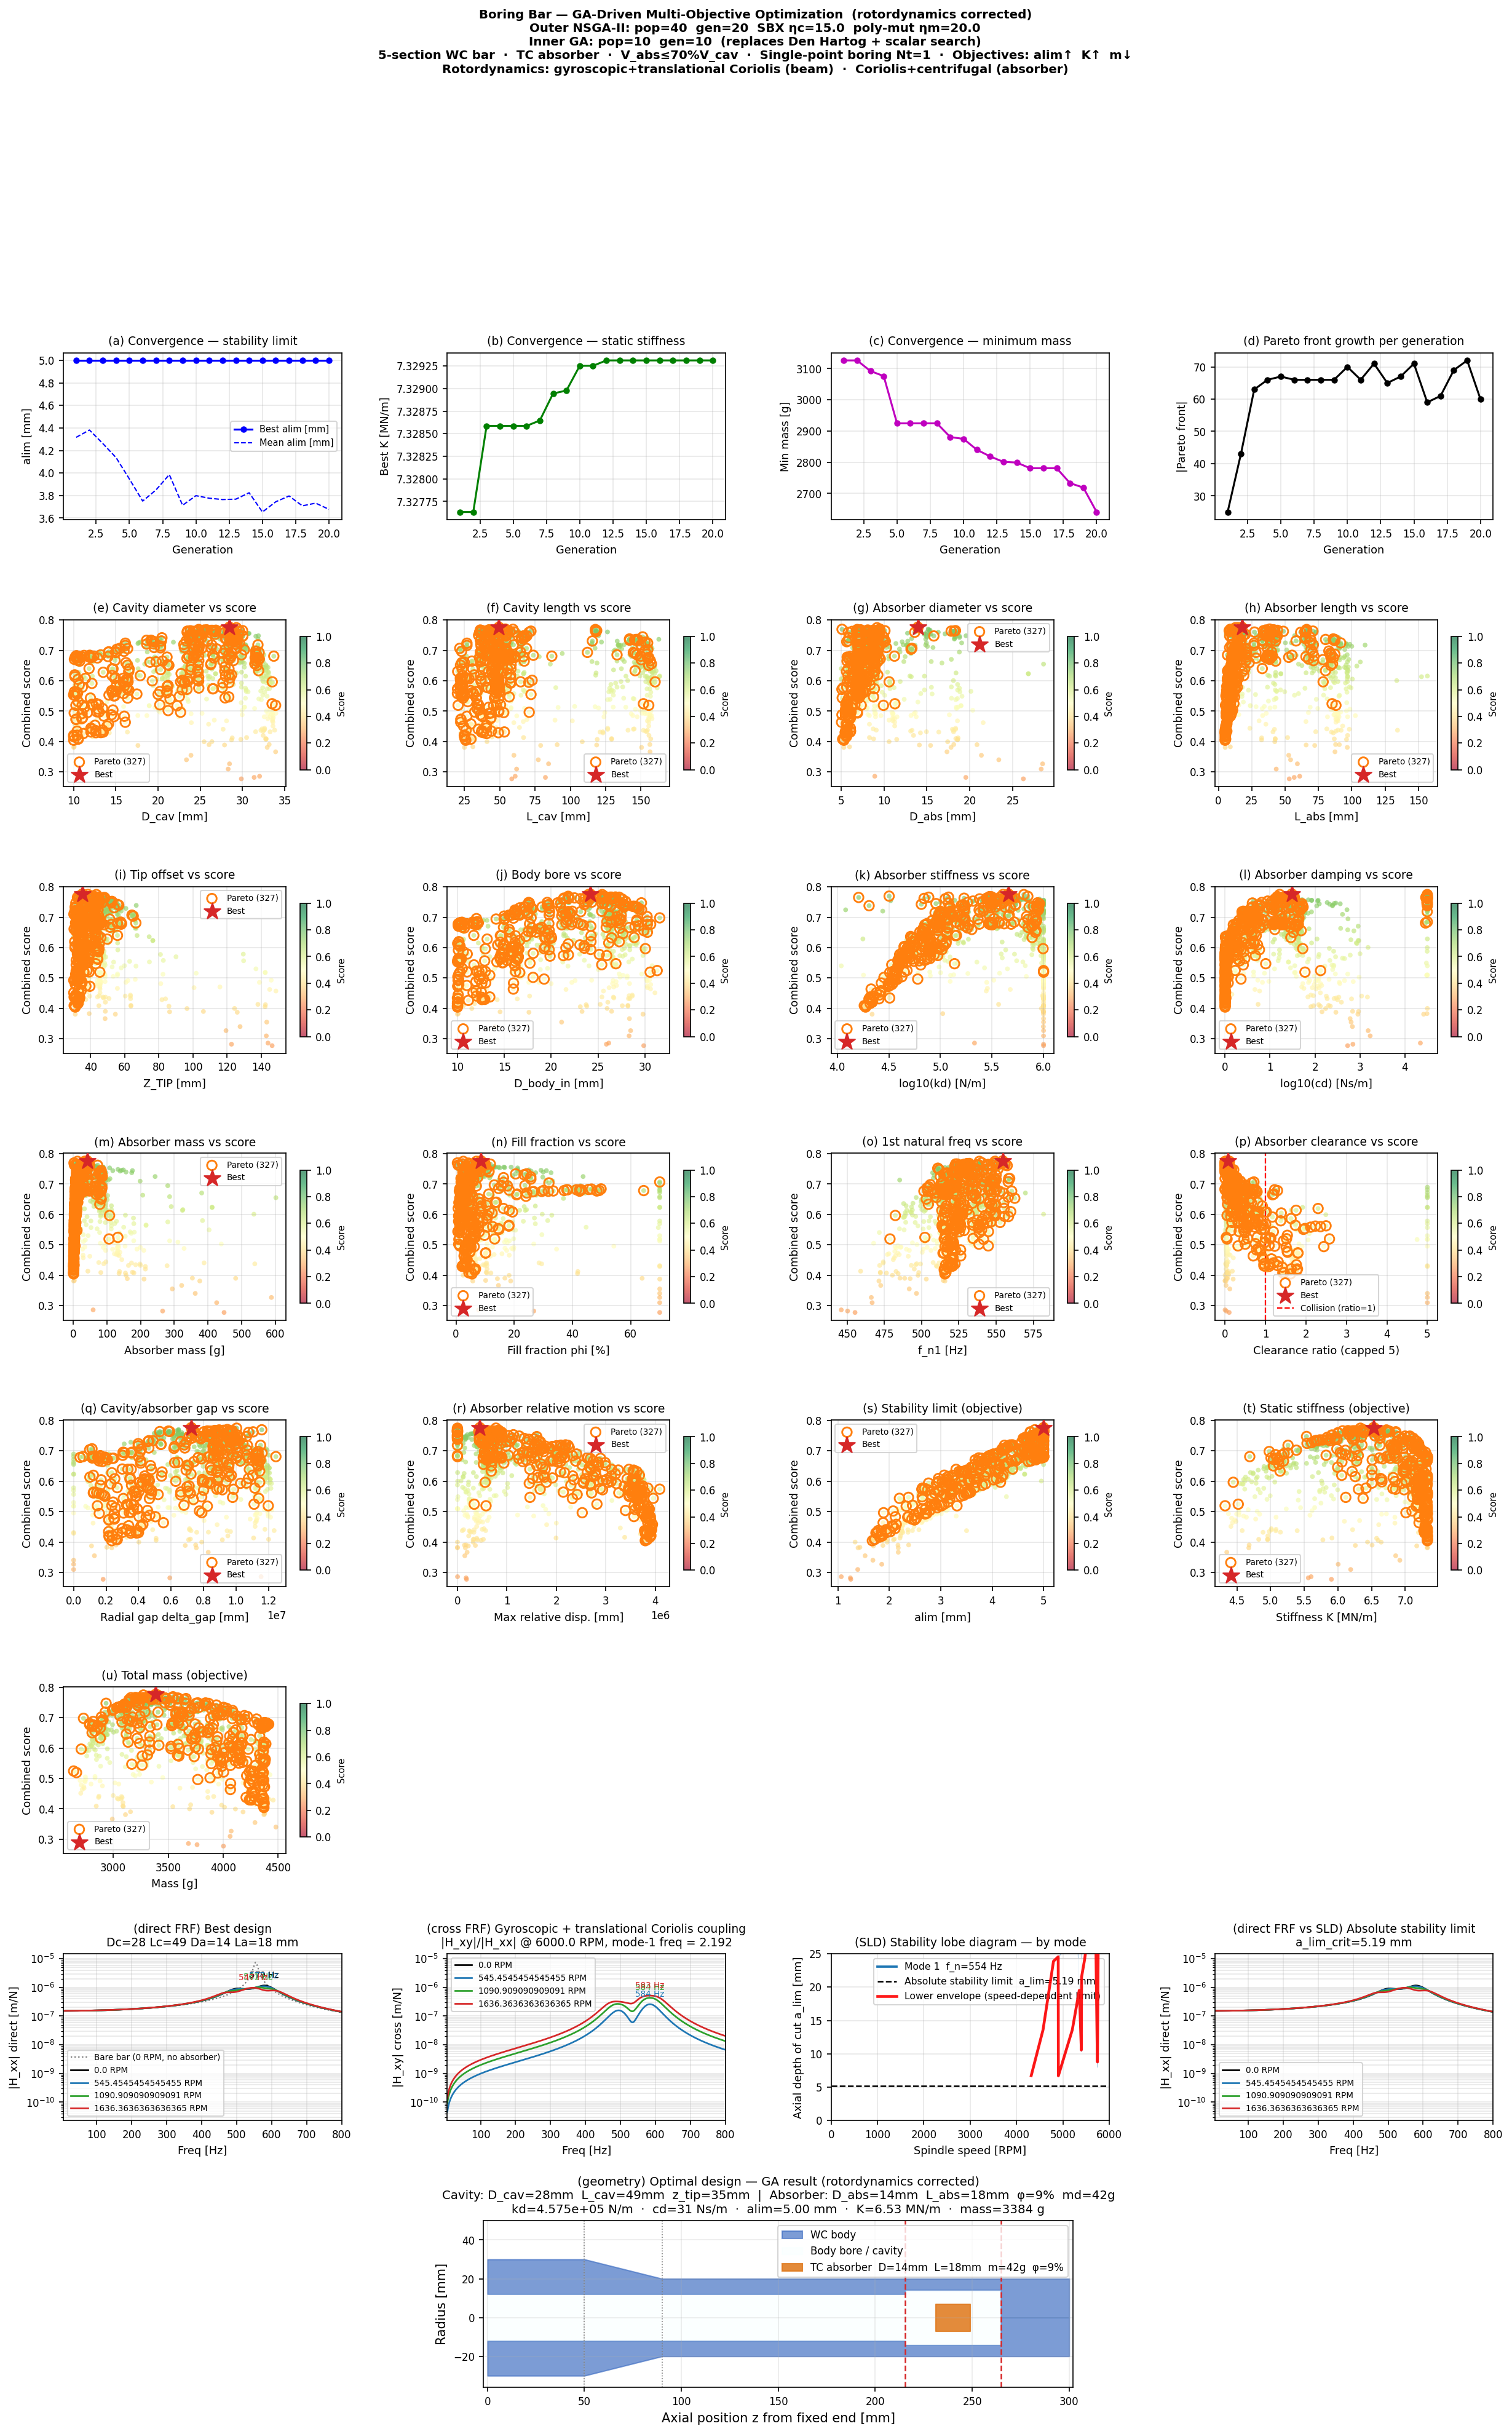

In [ ]:
# OPTIMIZATION (runtime): the original script called BOTH make_plot()
# (the original plotting routine) AND make_plots() (the rewritten
# version — see its docstring under "17. PLOTTING (REWRITTEN)", which
# explicitly states it replaces make_plot's role) back to back. That
# meant every expensive plotting computation — the multi-speed FRF
# sweep, the mode-resolved stability-lobe-diagram calculation, etc. —
# was run TWICE for no benefit, since make_plots() already produces a
# superset of what make_plot() shows. Only make_plots() is called now;
# make_plot() itself is left defined above (unused) rather than deleted,
# in case it is wanted for quick comparisons later.
make_plots(all_results, pareto_front, history)